In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import random
import shutil

2026-03-02 04:42:58.438613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772426578.632974      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772426578.689535      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772426579.136304      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772426579.136346      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772426579.136349      55 computation_placer.cc:177] computation placer alr

In [2]:
!pip install ultralytics
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:0000:01


In [3]:
from ultralytics import YOLO
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# **Yolo11n-960**

In [5]:
pretrained_model = YOLO("yolo11x.pt")

results = pretrained_model.train(
    data="/kaggle/input/datasets/munazermontasirakash/data-yaml-kaggle/data.yaml",
    epochs=100,
    imgsz=960,
    batch=8,

    lr0=0.003,
    lrf=0.1,
    
    mosaic=0.5,       
    mixup=0.1,
    fliplr=0.5,
    degrees=2.0,
    translate=0.05,
    scale=0.3,

    patience=30,
    project="/kaggle/working/sku_detection",
    name="yolo11x_aug_ft"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/munazermontasirakash/data-yaml-kaggle/data.yaml, degrees=2.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=yolo11x_aug_ft, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

In [7]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11x_aug_ft/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/munazermontasirakash/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.25,      # lower threshold
    iou=0.5,
    plots=True
)

# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11x summary (fused): 191 layers, 56,914,804 parameters, 0 gradients, 194.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 17.7±3.4 MB/s, size: 101.8 KB)
val: Scanning /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 309.8it/s 0.1s.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.2s/it 9.5s8.5s1s
                   all         35        145       0.74      0.832      0.823      0.528
                    12          1          3        0.6          1      0.995       0.62
                    13          1          3          1          1      0.995      0.703
                    14      

In [8]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11x_aug_ft/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/munazermontasirakash/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.15,      # lower threshold
    iou=0.5,
    plots=True
)

# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11x summary (fused): 191 layers, 56,914,804 parameters, 0 gradients, 194.9 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.2 ms, read: 175.8±44.3 MB/s, size: 88.8 KB)
val: Scanning /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 1.1Kit/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.7s/it 8.2s7.2s1s
                   all         35        145      0.715      0.835      0.828      0.523
                    12          1          3        0.6          1      0.995       0.62
                    13          1          3          1          1      0.995      0.703
                    14         

In [9]:
import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def compute_share_of_shelf(model, test_path, conf=0.20, iou=0.6, visualize=True):

    # Run prediction
    results = model.predict(
        source=test_path,
        conf=conf,
        iou=iou,
        save=False,
        verbose=False
    )

    # Count detections per class
    class_counts = Counter()

    for r in results:
        if r.boxes is not None:
            for cls in r.boxes.cls:
                class_id = int(cls.item())
                class_counts[class_id] += 1

    # Total detections
    total_detections = sum(class_counts.values())

    if total_detections == 0:
        print("No detections found.")
        return None

    # Compute Share of Shelf
    data = []
    for class_id, count in class_counts.items():
        share = (count / total_detections) * 100
        data.append([class_id, count, share])

    df = pd.DataFrame(data, columns=["Class_ID", "Count", "Share_of_Shelf (%)"])
    df = df.sort_values(by="Share_of_Shelf (%)", ascending=False)

    # Visualization
    if visualize:
        plt.figure(figsize=(14,6))
        plt.bar(df["Class_ID"], df["Share_of_Shelf (%)"])
        plt.xlabel("SKU (Class ID)")
        plt.ylabel("Share of Shelf (%)")
        plt.title("Share of Shelf per SKU")
        plt.xticks(rotation=90)
        plt.show()

    return df

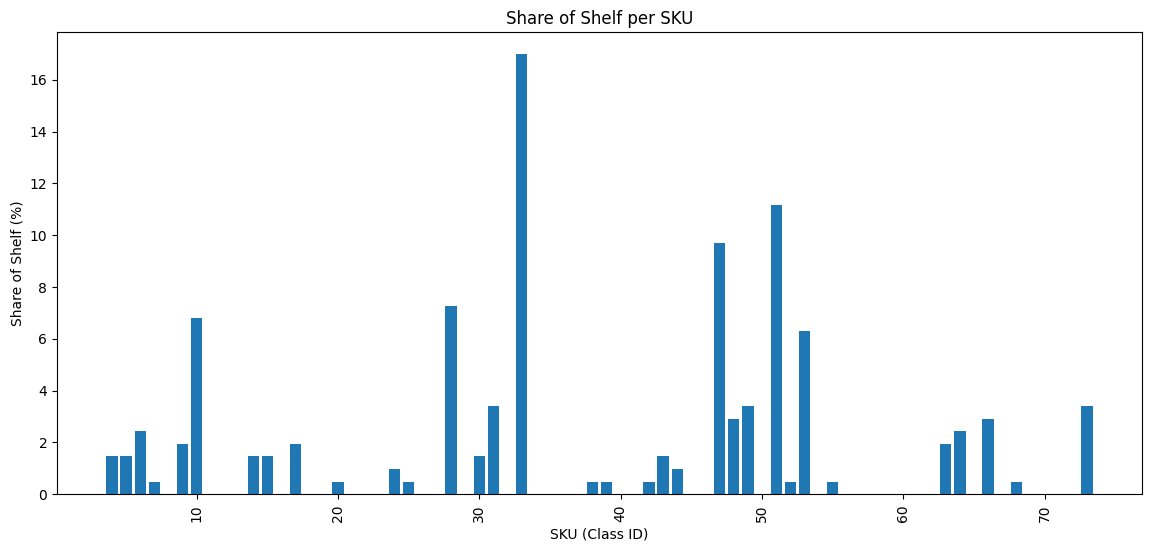

,Class_ID,Count,Share_of_Shelf (%)
4,33,35,16.990291
14,51,23,11.165049
16,47,20,9.708738
13,28,15,7.281553
28,10,14,6.796117
25,53,13,6.310680
31,31,7,3.398058
27,49,7,3.398058
29,73,7,3.398058
3,48,6,2.912621


In [10]:
test_path = "/kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.25, iou=0.5, visualize=True)

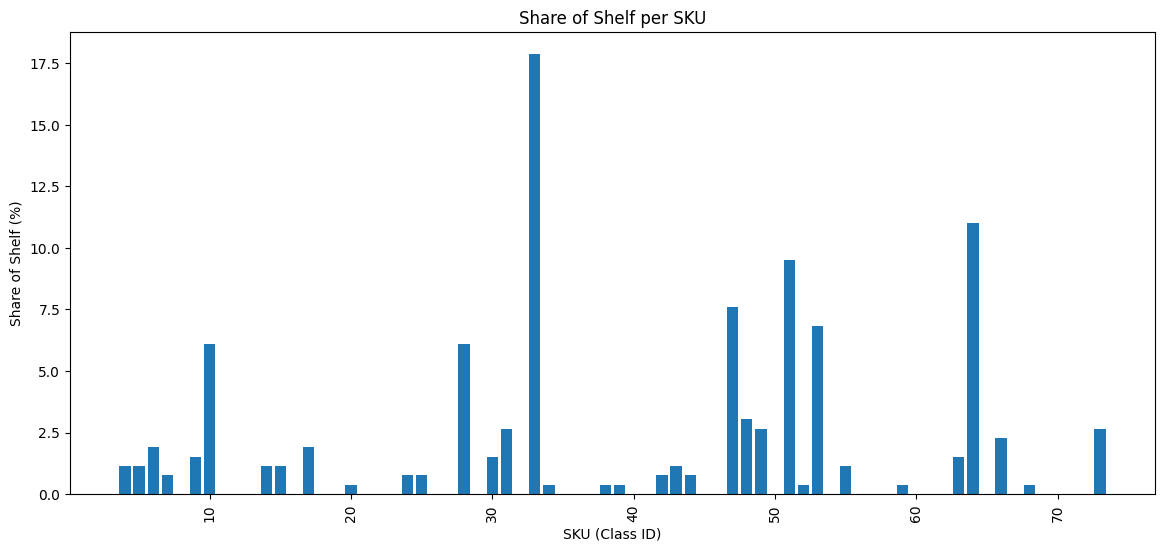

,Class_ID,Count,Share_of_Shelf (%)
4,33,47,17.870722
13,64,29,11.026616
16,51,25,9.505703
18,47,20,7.604563
27,53,18,6.844106
30,10,16,6.083650
15,28,16,6.083650
3,48,8,3.041825
29,49,7,2.661597
33,31,7,2.661597


In [11]:
test_path = "/kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.15, iou=0.5, visualize=True)